In [9]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#Importing data
nhts_data = pd.read_csv("NHTS.csv")
ngsim_data = pd.read_csv("NGSIM.csv")

#Set a style for the graphs
sns.set_style('whitegrid')
sns.set_palette('deep')

# Bar Chart

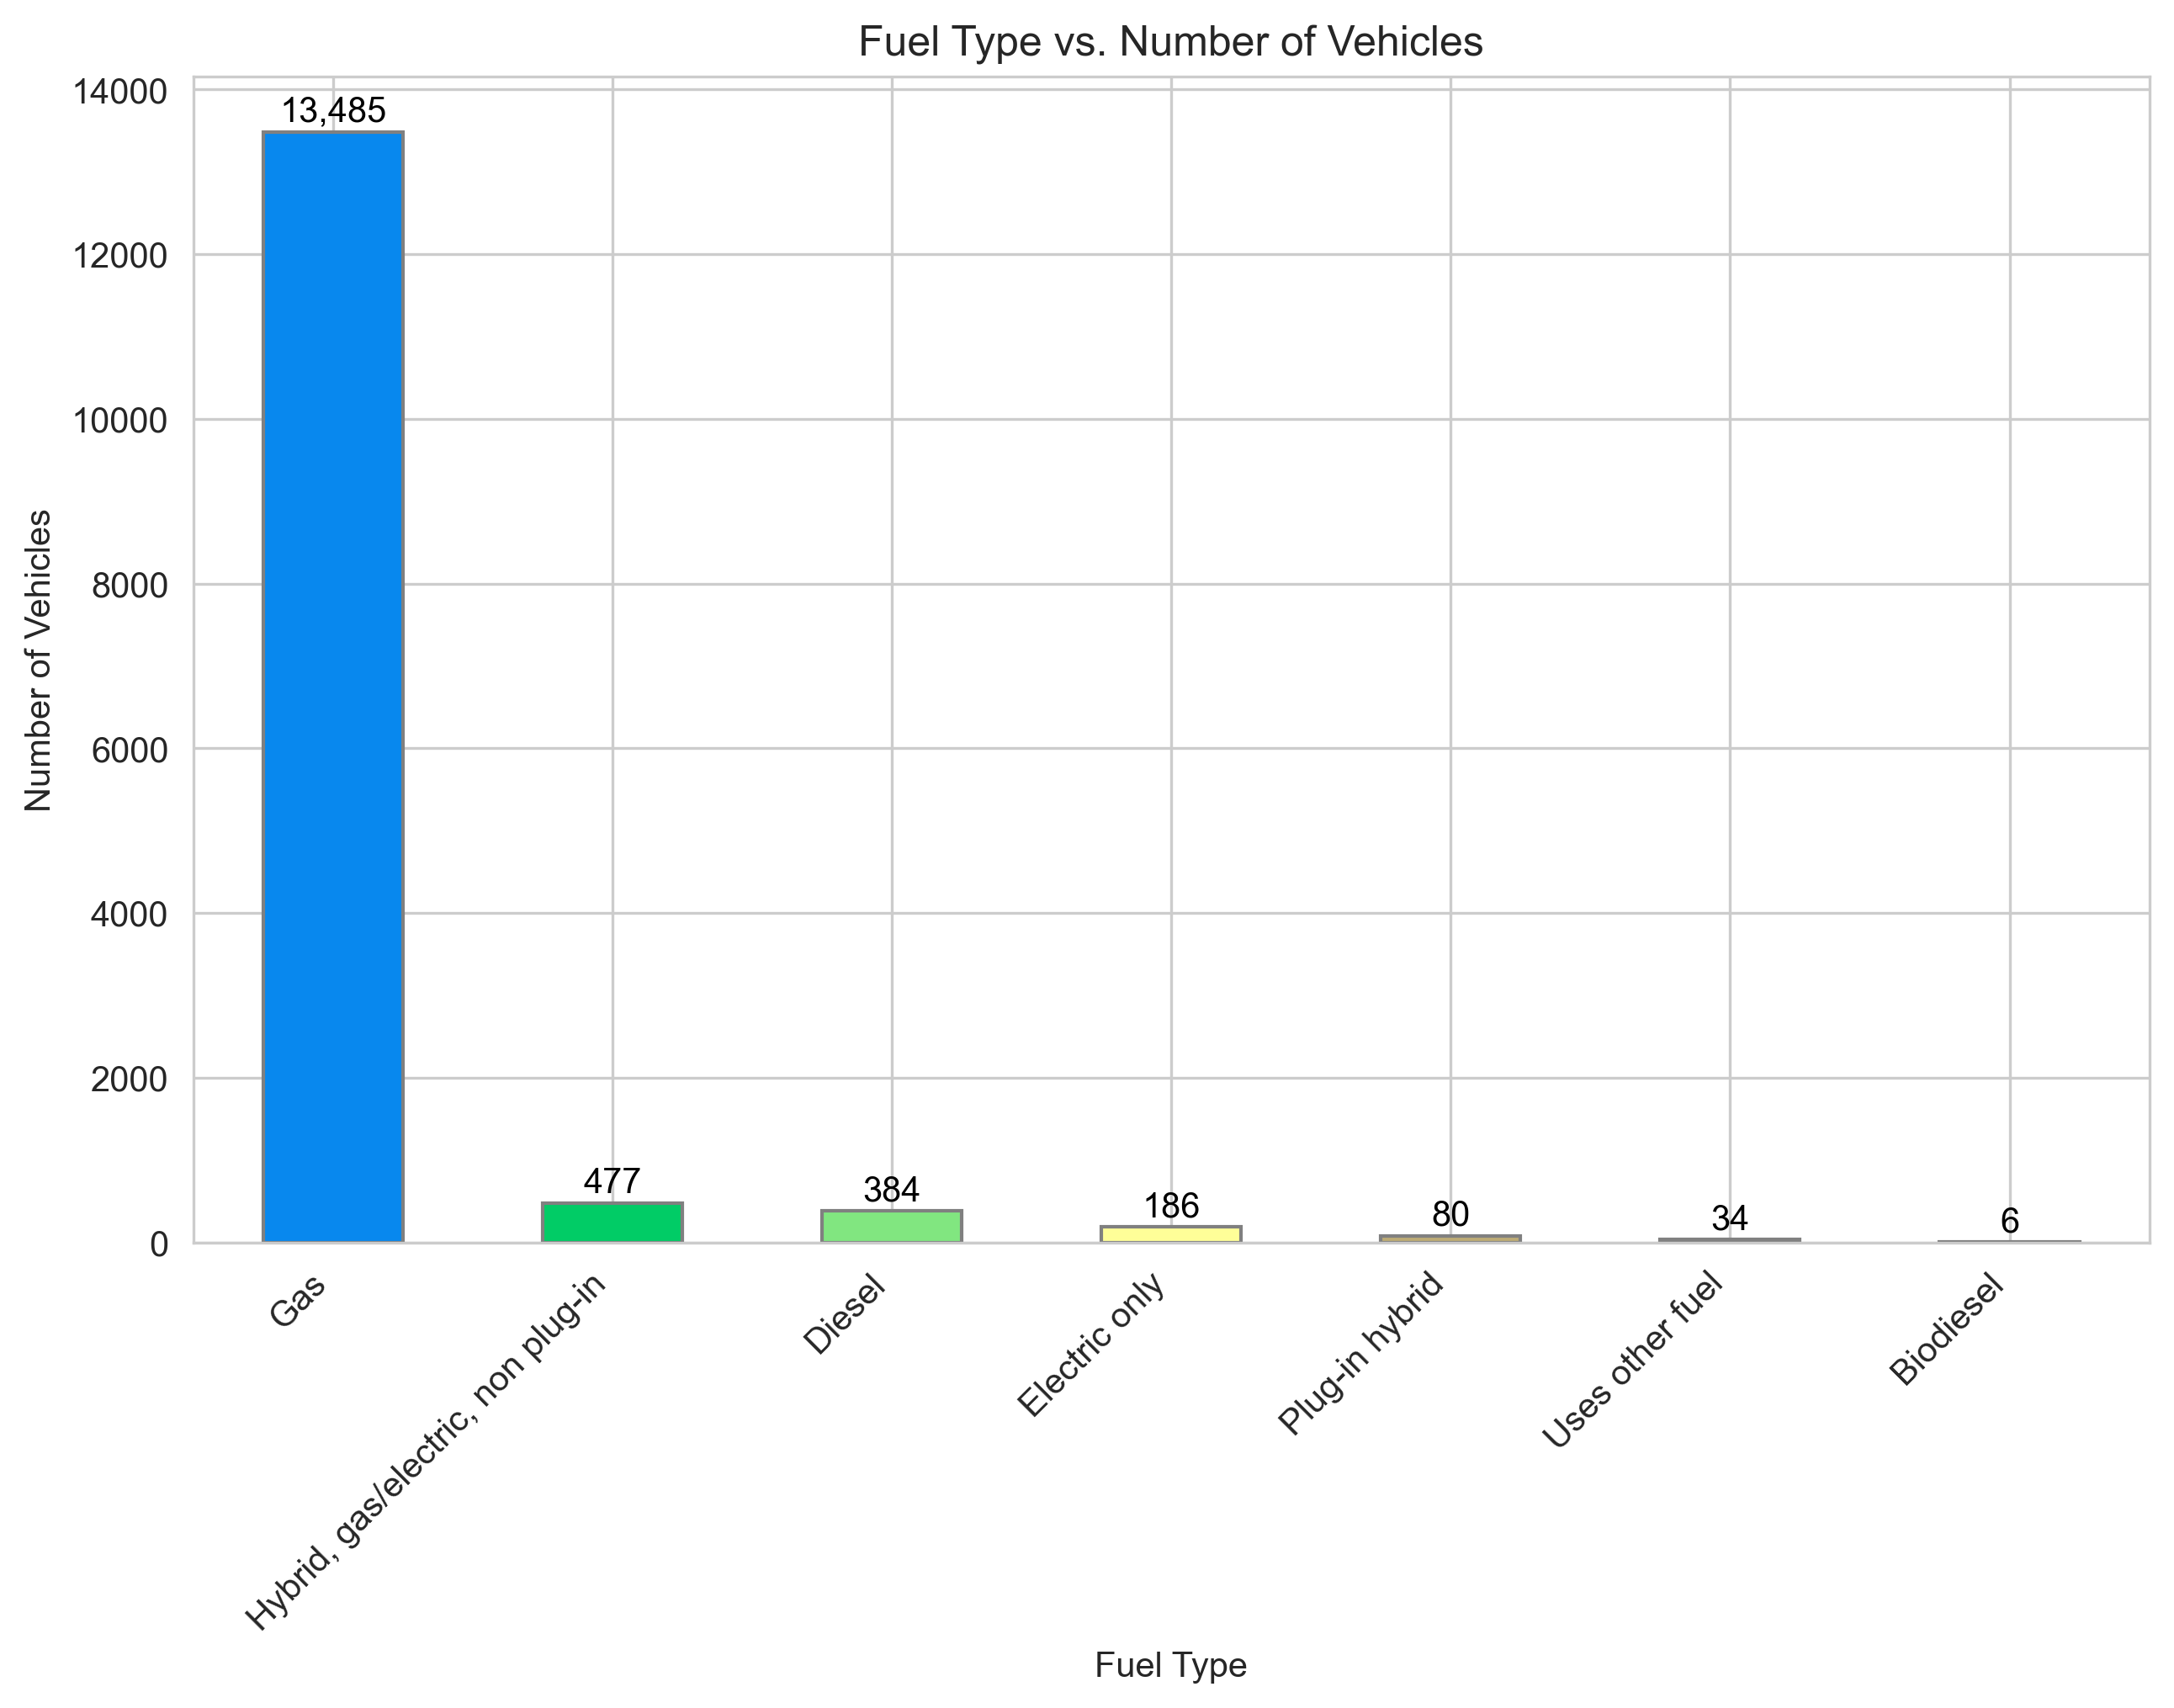

In [45]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot

fuel_counts = nhts_data['fuel_type'].value_counts().dropna()



## Step 2: create the bar plot and labels
plt.figure(figsize = (10,6), dpi=300)
fuel_counts.plot(kind = 'bar', color=sns.color_palette('terrain', len(fuel_counts)), edgecolor='grey')
plt.xlabel("Fuel Type")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Vehicles')
plt.title('Fuel Type vs. Number of Vehicles')

## Step 3: Add the value labels to the top of each bar
ax = plt.gca()
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
        bar.get_height() + 50,               # y position (just above the bar)
        f'{int(bar.get_height()):,}',        # value formatted with commas
        ha='center', va='bottom',
        fontsize=10, color='Black')


## Step 4: show the plot
plt.show()

# Histogram

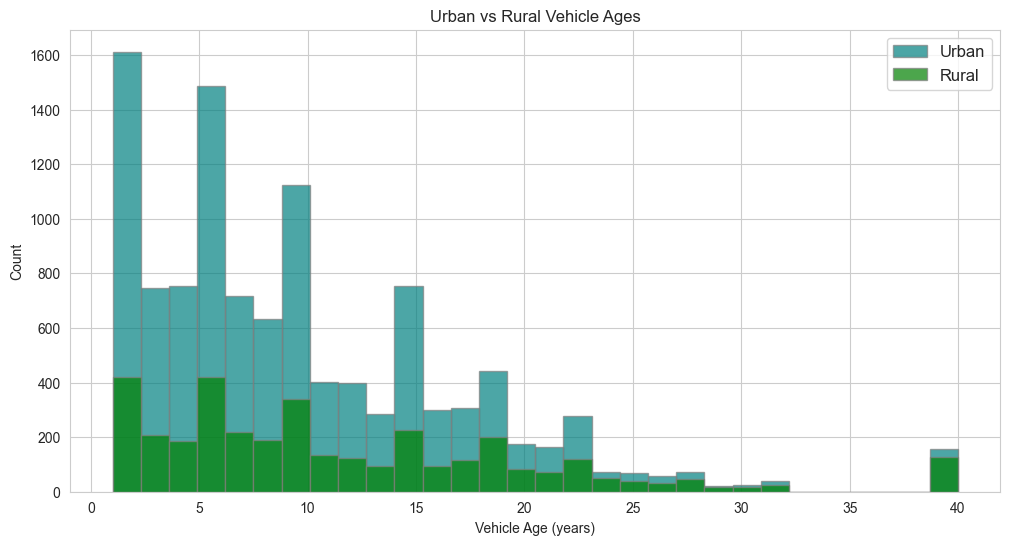

In [84]:
# Create overlapping histograms for Urban vs Rural vehicle ages
# We need to filter the data first, then plot each group separately

## Step 1: tell Python you are making a figure
plt.figure(figsize = (12,6))

## Step 2: filter and plot Urban vehicle ages
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 30, edgecolor='grey', alpha=0.7, color='teal', label = 'Urban')

## Step 3: filter and plot Rural vehicle ages on the same figure
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 30, edgecolor='grey', alpha=0.7, color='green', label = 'Rural')

## Step 4: add labels, title, and legend
plt.xlabel('Vehicle Age (years)')
plt.legend(fontsize = 12)
plt.ylabel('Count')
plt.title('Urban vs Rural Vehicle Ages')
plt.show()


# Boxplot

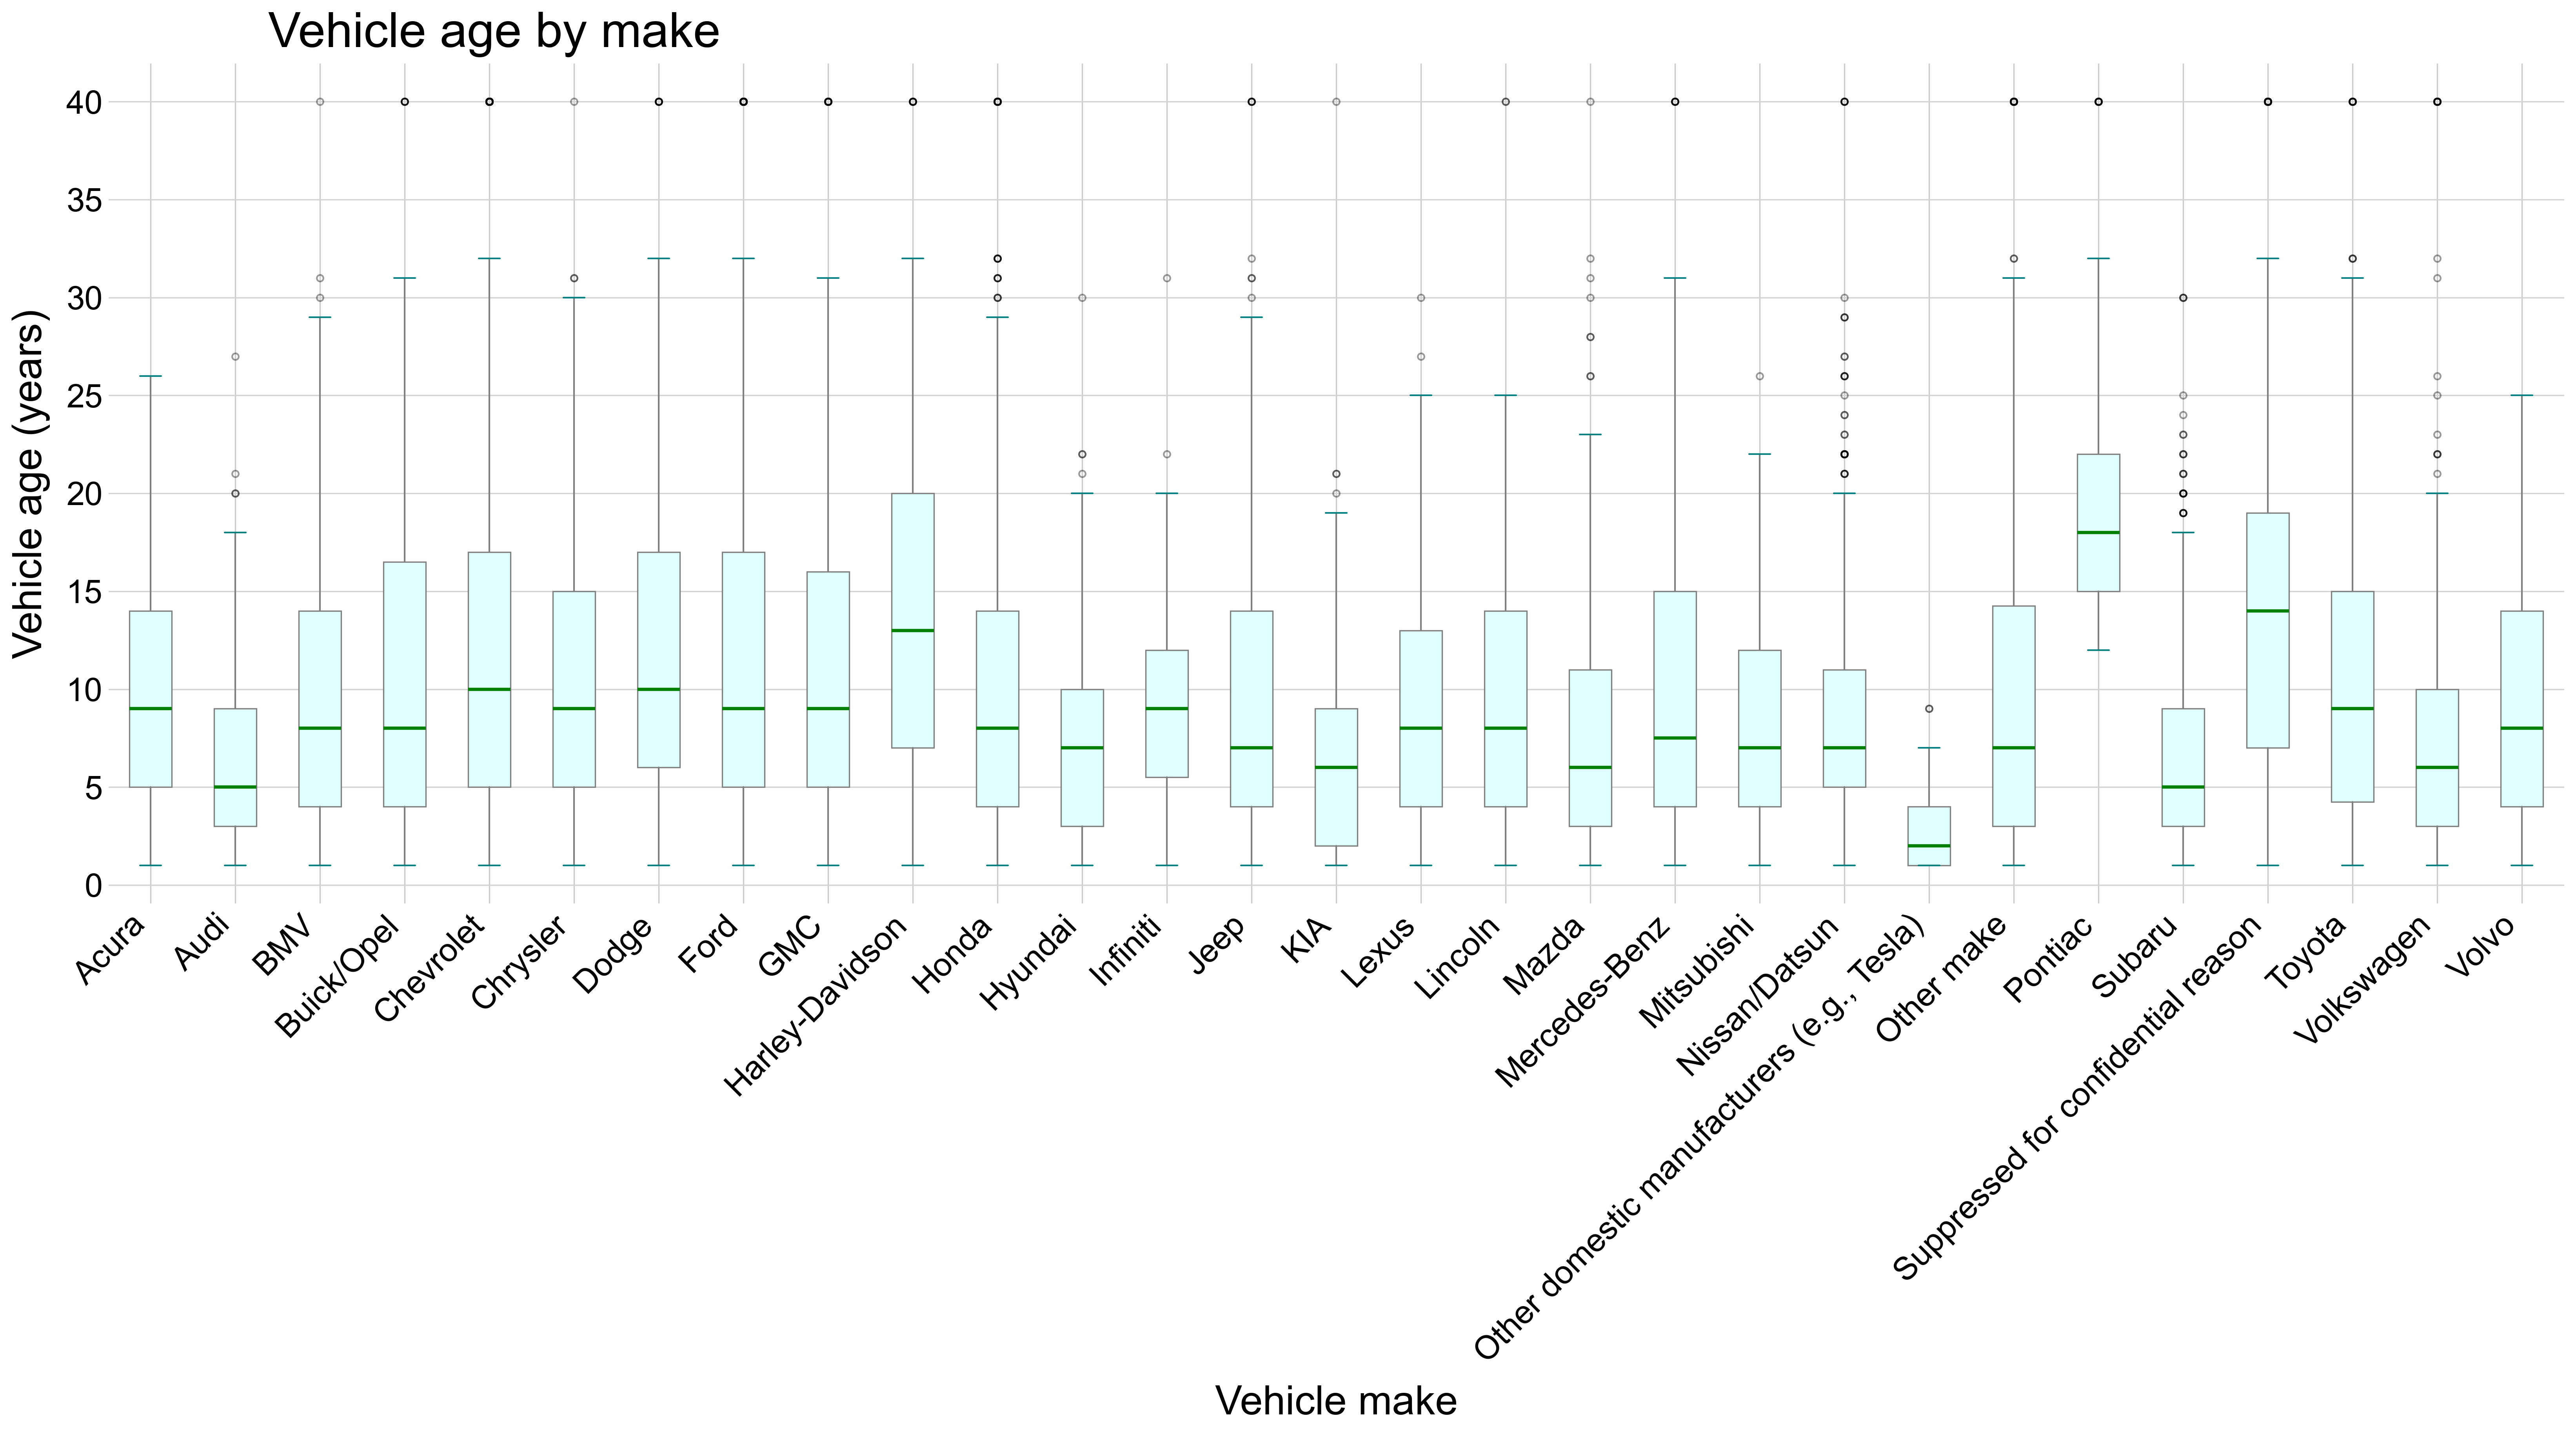

In [81]:


fig, ax = plt.subplots(figsize=(22, 12), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Use your actual dataframe here
bp = nhts_data.boxplot(
    column='vehicle_age',
    by='make',
    ax=ax,
    patch_artist=True,       # enables fill color on boxes
    return_type='dict',
    showfliers=True,
    whiskerprops=dict(color='gray', linewidth=1),
    capprops=dict(color='teal', linewidth=1),
    medianprops=dict(color='green', linewidth=2),   # teal median line
    flierprops=dict(marker='o', color='blue', alpha=0.4,
                    markerfacecolor='none', markersize=4),
    boxprops=dict(linewidth=0.8))

# Fill boxes with a light cyan
for patch in bp['vehicle_age']['boxes']:
    patch.set_facecolor('lightcyan')
    patch.set_edgecolor('gray')

# Clean up spines and grid
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.yaxis.grid(True, color='lightgray', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='both', length=0)

# Axis labels
ax.set_xlabel('Vehicle make', fontsize=25, color='black', labelpad=10)
ax.set_ylabel('Vehicle age (years)', fontsize=25, color='black', labelpad=10)
ax.tick_params(axis='x', labelrotation=45, labelsize=20, colors='black')
ax.tick_params(axis='y', labelsize=20, colors='black')

# Align rotated x labels to the right so they sit under their tick
for label in ax.get_xticklabels():
    label.set_ha('right')

# Remove the ugly auto-generated suptitle pandas adds
ax.set_title('')
plt.suptitle('')

# Custom title block
fig.text(0.065, 1.02, 'Vehicle age by make',
         fontsize=30, fontweight='medium', color='Black', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Time-Series Plot #1

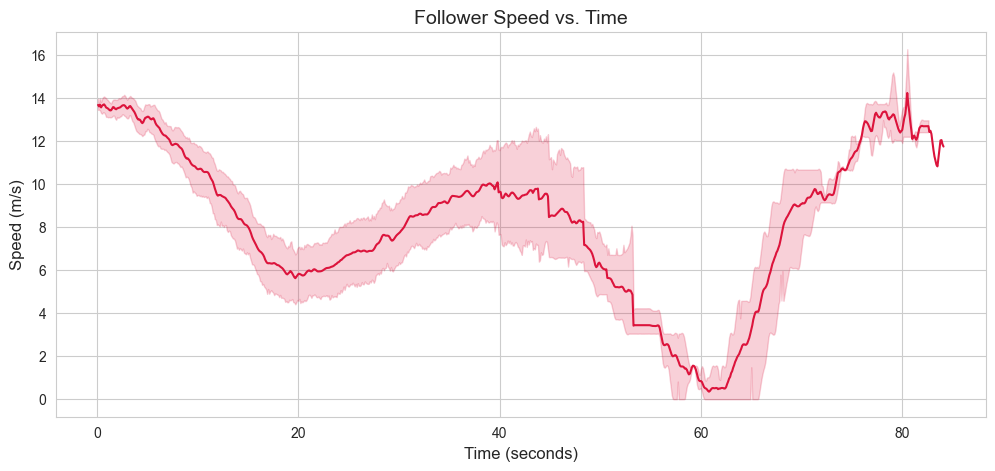

In [60]:
### Plotting Speed vs Time

plt.figure(figsize=(12,5))

sns.lineplot(x=ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'], color = 'crimson')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Follower Speed vs. Time', fontsize = 14)

plt.show()


# Time-Series Plot #2

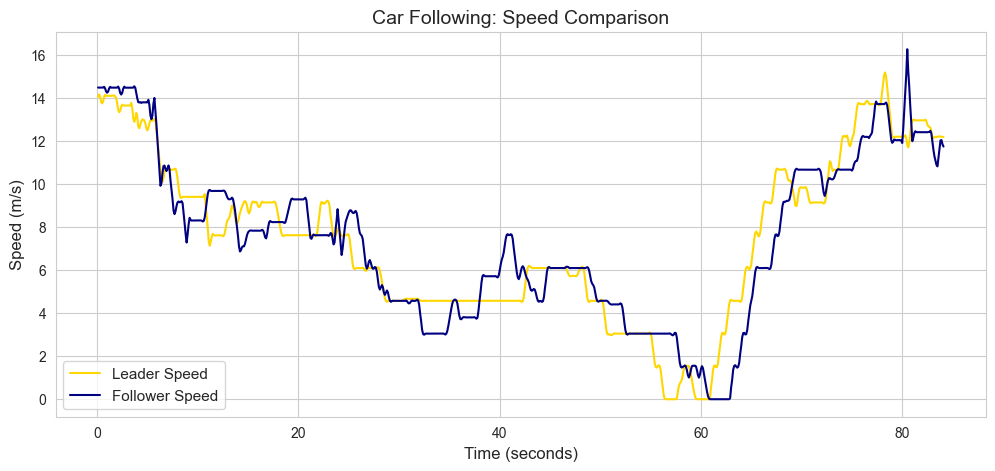

In [72]:
#Comparison of Follower and Leader speed for trajectory 1
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
plt.figure(figsize=(12,5))
sns.lineplot(x=data_subset['Time'], y= data_subset['leader_speed(m/s)'], label = 'Leader Speed', color = 'gold')
sns.lineplot(x=data_subset['Time'], y= data_subset['follower_speed(m/s)'], label = 'Follower Speed', color = 'navy')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Car Following: Speed Comparison', fontsize = 14)

plt.legend(fontsize=11)

plt.show()



# Simulation Study

In [86]:
#Define the Function for acceleration
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration

trajectory_number = 2
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

dt = time_data[1] - time_data[0]

# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

n_steps = len(time_data)
sim_position = np.zeros(n_steps)   # simulated follower position
sim_speed = np.zeros(n_steps)      # simulated follower speed
sim_acc = np.zeros(n_steps)        # simulated follower acceleration

sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

for i in range(n_steps - 1):
    gap = leader_position[i] - sim_position[i] #Difference in position
    gap = max(gap, 0.1) #makes sure that the gap is positive
    delta_v = sim_speed[i] - leader_speed[i] #Difference in speed
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta) #uses the defined equation to calc. acceleration
    sim_speed[i+1] = sim_speed[i+1] = sim_speed[i] + sim_acc[i] * dt #updates speed for the next time data value
    sim_speed[i+1] = max(sim_speed[i+1], 0)  # speed cannot be negative
    sim_position[i+1] = sim_position[i+1] = sim_position[i] + sim_speed[i] * dt #updates position

# Calculate the last acceleration value
gap = leader_position[-1] - sim_position[-1]
gap = max(gap, 0.1)
delta_v = sim_speed[-1] - leader_speed[-1]
sim_acc[-1] = idm_acceleration(sim_speed[-1], gap, delta_v, v0, s0, T, a_param, b, delta)

print("Simulation complete")
print(f"Final simulated position: {sim_position[-1]:.2f} m")
print(f"Final simulated speed: {sim_speed[-1]:.2f} m/s")

Simulation complete
Final simulated position: 417.97 m
Final simulated speed: 13.29 m/s


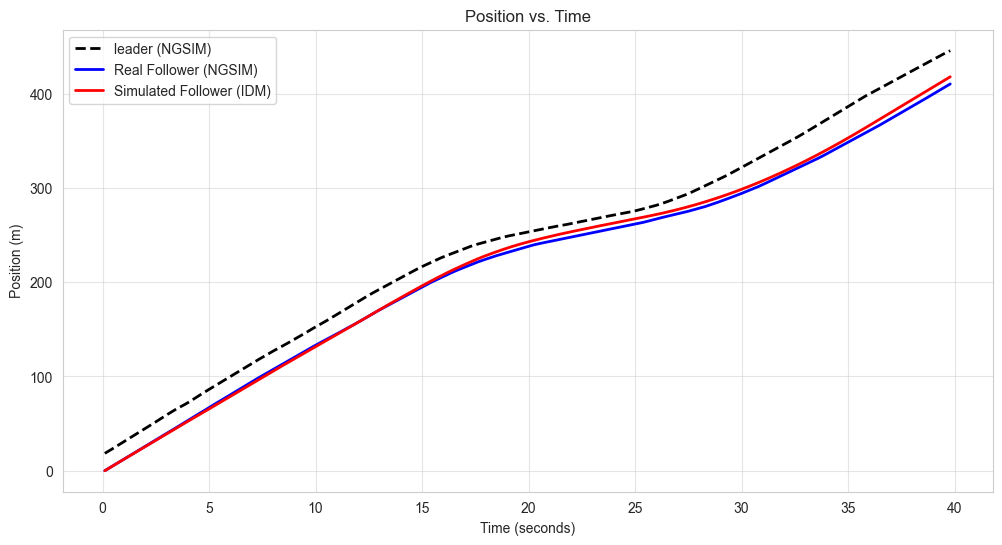

In [79]:
#Visualizing simulation results
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'leader (NGSIM)') #plot leader position vs. time
plt.plot(time_data, data_subset['follower_position(m)'].values, 'b-', linewidth = 2, label = 'Real Follower (NGSIM)')
plt.plot(time_data, sim_position, 'r-', linewidth = 2, label = 'Simulated Follower (IDM)')

plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('Position vs. Time')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()